# Single-cell RNA-seq Analysis: Resident Memory T Cell Development

This notebook analyzes single-cell RNA-seq data from GSE237735, focusing on resident memory T cell development across all available timepoints and tissues.

## Analysis Overview:
- Processes all .h5 files in the current directory
- Applies quality control filtering (min_counts=1000, min_genes=500)
- Combines all samples into a single AnnData object
- Extracts sample metadata from filenames
- Performs comprehensive quality control analysis


In [ ]:
# Import necessary libraries
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pathlib import Path
import re
from typing import List, Dict, Tuple

# Set scanpy settings
sc.settings.verbosity = 3  # verbosity level
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [ ]:
# Find all .h5 files in the current directory
data_dir = Path('.')
h5_files = sorted(list(data_dir.glob('*.h5')))

print(f"Found {len(h5_files)} .h5 files:")
for i, file in enumerate(h5_files, 1):
    print(f"  {i:2d}. {file.name}")

if len(h5_files) == 0:
    print("No .h5 files found in the current directory!")
    raise FileNotFoundError("No .h5 files found")


Found 19 .h5 files:
   1. GSM7646289_1_D2_LN_raw_feature_bc_matrix.h5
   2. GSM7646290_2_D15_LN_raw_feature_bc_matrix.h5
   3. GSM7646291_3_D25_LN_raw_feature_bc_matrix.h5
   4. GSM7646292_4_D25_Skin_raw_feature_bc_matrix.h5
   5. GSM7646293_5_D0_Naive_raw_feature_bc_matrix.h5
   6. GSM7646294_6_D10_LN_raw_feature_bc_matrix.h5
   7. GSM7646295_7_D10_Skin_raw_feature_bc_matrix.h5
   8. GSM7646296_8_D15_Skin_raw_feature_bc_matrix.h5
   9. GSM7646297_9_D5_LN_raw_feature_bc_matrix.h5
  10. GSM7646298_10_D5_Skin_raw_feature_bc_matrix.h5
  11. GSM7646299_11_D20_LN_raw_feature_bc_matrix.h5
  12. GSM7646300_12_D45_LN_raw_feature_bc_matrix.h5
  13. GSM7646301_13_D20_Skin_raw_feature_bc_matrix.h5
  14. GSM7646302_14_D45_Skin_raw_feature_bc_matrix.h5
  15. GSM7646303_15_D30_LN_raw_feature_bc_matrix.h5
  16. GSM7646304_16_D60_LN_raw_feature_bc_matrix.h5
  17. GSM7646305_17_D30_Skin_raw_feature_bc_matrix.h5
  18. GSM7646306_18_D60_Skin_raw_feature_bc_matrix.h5
  19. GSM7646307_19_D30_Skin_raw_featu

In [ ]:
# Function to extract metadata from filename
def extract_metadata(filename: str) -> Dict[str, str]:
    """Extract sample metadata from filename"""
    # Pattern: GSM7646XXX_Y_timepoint_tissue_raw_feature_bc_matrix.h5
    # Example: GSM7646289_1_D2_LN_raw_feature_bc_matrix.h5
    
    pattern = r'GSM(\d+)_(\d+)_([^_]+)_([^_]+)_raw_feature_bc_matrix\.h5'
    match = re.match(pattern, filename)
    
    if match:
        gsm_id, sample_num, timepoint, tissue = match.groups()
        return {
            'gsm_id': f'GSM{gsm_id}',
            'sample_number': sample_num,
            'timepoint': timepoint,
            'tissue': tissue,
            'sample_id': f'GSM{gsm_id}_{sample_num}_{timepoint}_{tissue}'
        }
    else:
        # Fallback for non-standard filenames
        base_name = filename.replace('_raw_feature_bc_matrix.h5', '')
        return {
            'gsm_id': 'Unknown',
            'sample_number': 'Unknown', 
            'timepoint': 'Unknown',
            'tissue': 'Unknown',
            'sample_id': base_name
        }

# Test metadata extraction
print("Testing metadata extraction:")
for file in h5_files[:3]:  # Show first 3 files
    metadata = extract_metadata(file.name)
    print(f"  {file.name} -> {metadata}")


Testing metadata extraction:
  GSM7646289_1_D2_LN_raw_feature_bc_matrix.h5 -> {'gsm_id': 'GSM7646289', 'sample_number': '1', 'timepoint': 'D2', 'tissue': 'LN', 'sample_id': 'GSM7646289_1_D2_LN'}
  GSM7646290_2_D15_LN_raw_feature_bc_matrix.h5 -> {'gsm_id': 'GSM7646290', 'sample_number': '2', 'timepoint': 'D15', 'tissue': 'LN', 'sample_id': 'GSM7646290_2_D15_LN'}
  GSM7646291_3_D25_LN_raw_feature_bc_matrix.h5 -> {'gsm_id': 'GSM7646291', 'sample_number': '3', 'timepoint': 'D25', 'tissue': 'LN', 'sample_id': 'GSM7646291_3_D25_LN'}


In [ ]:
# Process all .h5 files using a loop
def process_single_sample(file_path: Path) -> ad.AnnData:
    """Process a single .h5 file with filtering"""
    print(f"Processing {file_path.name}...")
    
    # Load data
    adata = sc.read_10x_h5(file_path)
    adata.var_names_make_unique()
    
    # Extract metadata from filename
    metadata = extract_metadata(file_path.name)
    
    # Add metadata to observations
    for key, value in metadata.items():
        adata.obs[key] = value
    
    print(f"  Original shape: {adata.shape}")
    
    # Apply filtering
    sc.pp.filter_cells(adata, min_counts=1000)   # drop empty droplets
    sc.pp.filter_cells(adata, min_genes=500)     # filter cells with too few genes
    
    print(f"  After filtering: {adata.shape}")
    
    return adata

# Process all samples
print("\\n" + "="*60)
print("PROCESSING ALL SAMPLES")
print("="*60)

processed_samples = []
for file_path in h5_files:
    try:
        adata_sample = process_single_sample(file_path)
        processed_samples.append(adata_sample)
        print(f"  ✓ Successfully processed {file_path.name}")
    except Exception as e:
        print(f"  ✗ Error processing {file_path.name}: {str(e)}")
        continue
    print()

print(f"Successfully processed {len(processed_samples)} out of {len(h5_files)} files")


\n============================================================
PROCESSING ALL SAMPLES
Processing GSM7646289_1_D2_LN_raw_feature_bc_matrix.h5...
reading GSM7646289_1_D2_LN_raw_feature_bc_matrix.h5
 (0:00:00)
  Original shape: (737280, 54533)
filtered out 730167 cells that have less than 1000 counts


e:\Anaconda\envs\bio\Lib\site-packages\anndata\_core\anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
e:\Anaconda\envs\bio\Lib\site-packages\anndata\_core\anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  After filtering: (7113, 54533)
  ✓ Successfully processed GSM7646289_1_D2_LN_raw_feature_bc_matrix.h5

Processing GSM7646290_2_D15_LN_raw_feature_bc_matrix.h5...
reading GSM7646290_2_D15_LN_raw_feature_bc_matrix.h5
 (0:00:00)
  Original shape: (737280, 54533)
filtered out 732061 cells that have less than 1000 counts
filtered out 1 cells that have less than 500 genes expressed
  After filtering: (5218, 54533)
  ✓ Successfully processed GSM7646290_2_D15_LN_raw_feature_bc_matrix.h5

Processing GSM7646291_3_D25_LN_raw_feature_bc_matrix.h5...
reading GSM7646291_3_D25_LN_raw_feature_bc_matrix.h5


e:\Anaconda\envs\bio\Lib\site-packages\anndata\_core\anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
e:\Anaconda\envs\bio\Lib\site-packages\anndata\_core\anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:00)
  Original shape: (737280, 54533)
filtered out 730666 cells that have less than 1000 counts
filtered out 1 cells that have less than 500 genes expressed


...

filtered out 9 cells that have less than 500 genes expressed
  After filtering: (1249, 54533)
  ✓ Successfully processed GSM7646306_18_D60_Skin_raw_feature_bc_matrix.h5

Processing GSM7646307_19_D30_Skin_raw_feature_bc_matrix.h5...
reading GSM7646307_19_D30_Skin_raw_feature_bc_matrix.h5


e:\Anaconda\envs\bio\Lib\site-packages\anndata\_core\anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


 (0:00:11)


e:\Anaconda\envs\bio\Lib\site-packages\anndata\_core\anndata.py:1793: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  Original shape: (6794880, 54533)
filtered out 6789334 cells that have less than 1000 counts
  After filtering: (5546, 54533)
  ✓ Successfully processed GSM7646307_19_D30_Skin_raw_feature_bc_matrix.h5

Successfully processed 19 out of 19 files


In [ ]:
# Combine all processed samples
if len(processed_samples) == 0:
    raise ValueError("No samples were successfully processed!")

print("\\n" + "="*60)
print("COMBINING ALL SAMPLES")
print("="*60)

# Combine datasets
adata_combined = ad.concat(processed_samples, join='outer', index_unique='_')

print(f"Combined data shape: {adata_combined.shape}")
print(f"Total cells: {adata_combined.n_obs}")
print(f"Total genes: {adata_combined.n_vars}")

# Display sample composition
print("\\nSample composition:")
sample_counts = adata_combined.obs['sample_id'].value_counts()
for sample, count in sample_counts.items():
    print(f"  {sample}: {count:,} cells")

print("\\nTimepoint distribution:")
timepoint_counts = adata_combined.obs['timepoint'].value_counts().sort_index()
for timepoint, count in timepoint_counts.items():
    print(f"  {timepoint}: {count:,} cells")

print("\\nTissue distribution:")
tissue_counts = adata_combined.obs['tissue'].value_counts()
for tissue, count in tissue_counts.items():
    print(f"  {tissue}: {count:,} cells")


\n============================================================
COMBINING ALL SAMPLES


Combined data shape: (102107, 54533)
Total cells: 102107
Total genes: 54533
\nSample composition:
  GSM7646293_5_D0_Naive: 7,701 cells
  GSM7646304_16_D60_LN: 7,277 cells
  GSM7646289_1_D2_LN: 7,113 cells
  GSM7646300_12_D45_LN: 6,842 cells
  GSM7646297_9_D5_LN: 6,735 cells
  GSM7646291_3_D25_LN: 6,613 cells
  GSM7646303_15_D30_LN: 6,465 cells
  GSM7646295_7_D10_Skin: 6,127 cells
  GSM7646299_11_D20_LN: 6,116 cells
  GSM7646294_6_D10_LN: 5,952 cells
  GSM7646307_19_D30_Skin: 5,546 cells
  GSM7646296_8_D15_Skin: 5,533 cells
  GSM7646290_2_D15_LN: 5,218 cells
  GSM7646298_10_D5_Skin: 5,000 cells
  GSM7646301_13_D20_Skin: 4,834 cells
  GSM7646292_4_D25_Skin: 3,176 cells
  GSM7646305_17_D30_Skin: 2,870 cells
  GSM7646302_14_D45_Skin: 1,740 cells
  GSM7646306_18_D60_Skin: 1,249 cells
\nTimepoint distribution:
  D0: 7,701 cells
  D10: 12,079 cells
  D15: 10,751 cells
  D2: 7,113 cells
  D20: 10,950 cells
  D25: 9,789 cells
  D30: 14,881 cells
  D45: 8,582 cells
  D5: 11,735 cells
  D60: 8,52

In [ ]:
# Calculate comprehensive QC metrics
print("\\n" + "="*60)
print("CALCULATING QC METRICS")
print("="*60)

# Make variable names unique
adata_combined.var_names_make_unique()

# Identify mitochondrial and ribosomal genes
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('mt-')  # mouse mitochondrial genes
adata_combined.var['ribo'] = adata_combined.var_names.str.startswith(('Rps', 'Rpl'))  # mouse ribosomal genes

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_combined, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['ribo'], percent_top=None, log1p=False, inplace=True)

print("QC metrics calculated successfully!")

# Display basic statistics
print("\\nQuality Control Statistics:")
print(f"\\nTotal UMI counts per cell:")
print(adata_combined.obs['total_counts'].describe())

print(f"\\nNumber of genes per cell:")
print(adata_combined.obs['n_genes_by_counts'].describe())

print(f"\\nMitochondrial gene percentage:")
print(adata_combined.obs['pct_counts_mt'].describe())

print(f"\\nRibosomal gene percentage:")
print(adata_combined.obs['pct_counts_ribo'].describe())


\n============================================================
CALCULATING QC METRICS
QC metrics calculated successfully!
\nQuality Control Statistics:
\nTotal UMI counts per cell:
count    102107.000000
mean       3214.591553
std        2302.464844
min        1000.000000
25%        1707.000000
50%        2409.000000
75%        4054.000000
max       40492.000000
Name: total_counts, dtype: float64
\nNumber of genes per cell:
count    102107.000000
mean       1437.758449
std         674.565321
min         500.000000
25%         937.000000
50%        1221.000000
75%        1812.000000
max        7152.000000
Name: n_genes_by_counts, dtype: float64
\nMitochondrial gene percentage:
count    102107.000000
mean          1.269125
std           0.762929
min           0.000000
25%           0.863418
50%           1.156069
75%           1.493529
max          60.090088
Name: pct_counts_mt, dtype: float64
\nRibosomal gene percentage:
count    102107.000000
mean         17.575611
std           5.5257

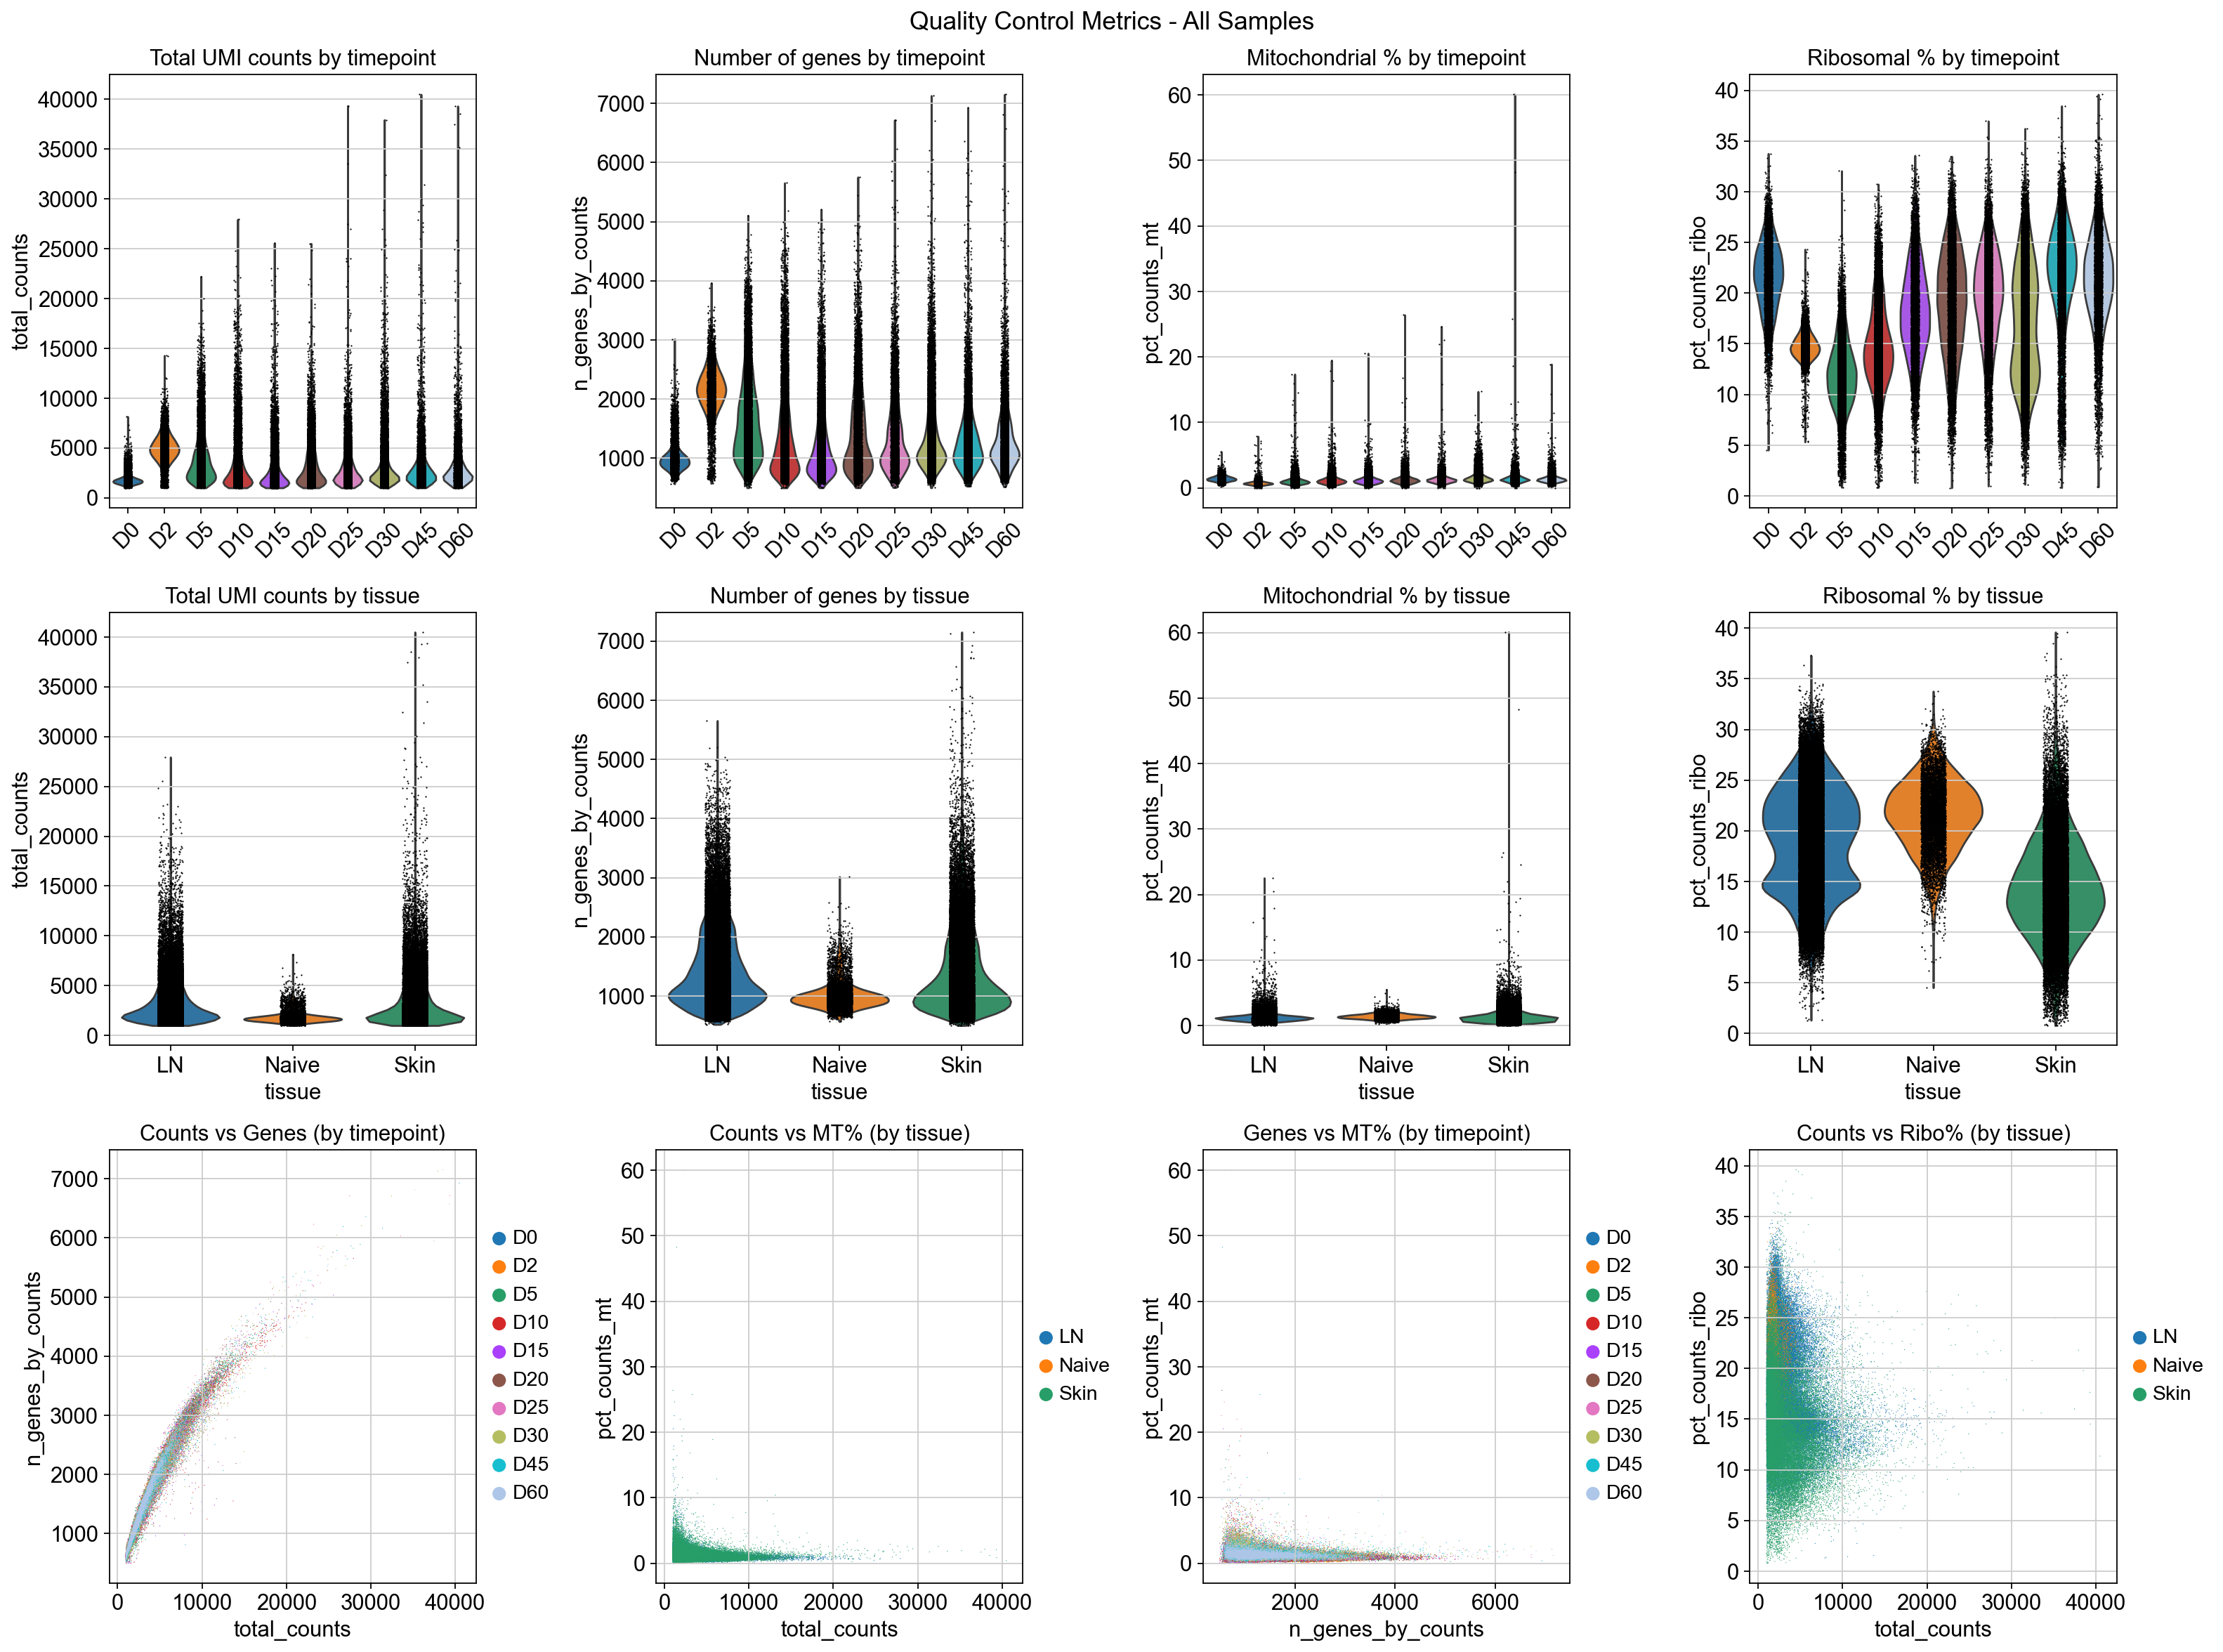

In [ ]:
# Create comprehensive QC plots
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Quality Control Metrics - All Samples', fontsize=16)

# Row 1: Violin plots by timepoint
sc.pl.violin(adata_combined, ['total_counts'], groupby='timepoint', ax=axes[0,0], show=False, rotation=45)
axes[0,0].set_title('Total UMI counts by timepoint')

sc.pl.violin(adata_combined, ['n_genes_by_counts'], groupby='timepoint', ax=axes[0,1], show=False, rotation=45)
axes[0,1].set_title('Number of genes by timepoint')

sc.pl.violin(adata_combined, ['pct_counts_mt'], groupby='timepoint', ax=axes[0,2], show=False, rotation=45)
axes[0,2].set_title('Mitochondrial % by timepoint')

sc.pl.violin(adata_combined, ['pct_counts_ribo'], groupby='timepoint', ax=axes[0,3], show=False, rotation=45)
axes[0,3].set_title('Ribosomal % by timepoint')

# Row 2: Violin plots by tissue
sc.pl.violin(adata_combined, ['total_counts'], groupby='tissue', ax=axes[1,0], show=False)
axes[1,0].set_title('Total UMI counts by tissue')

sc.pl.violin(adata_combined, ['n_genes_by_counts'], groupby='tissue', ax=axes[1,1], show=False)
axes[1,1].set_title('Number of genes by tissue')

sc.pl.violin(adata_combined, ['pct_counts_mt'], groupby='tissue', ax=axes[1,2], show=False)
axes[1,2].set_title('Mitochondrial % by tissue')

sc.pl.violin(adata_combined, ['pct_counts_ribo'], groupby='tissue', ax=axes[1,3], show=False)
axes[1,3].set_title('Ribosomal % by tissue')

# Row 3: Scatter plots
sc.pl.scatter(adata_combined, x='total_counts', y='n_genes_by_counts', color='timepoint', ax=axes[2,0], show=False)
axes[2,0].set_title('Counts vs Genes (by timepoint)')

sc.pl.scatter(adata_combined, x='total_counts', y='pct_counts_mt', color='tissue', ax=axes[2,1], show=False)
axes[2,1].set_title('Counts vs MT% (by tissue)')

sc.pl.scatter(adata_combined, x='n_genes_by_counts', y='pct_counts_mt', color='timepoint', ax=axes[2,2], show=False)
axes[2,2].set_title('Genes vs MT% (by timepoint)')

sc.pl.scatter(adata_combined, x='total_counts', y='pct_counts_ribo', color='tissue', ax=axes[2,3], show=False)
axes[2,3].set_title('Counts vs Ribo% (by tissue)')

plt.tight_layout()
plt.show()


In [ ]:
# Save the combined dataset
print("\\n" + "="*60)
print("SAVING COMBINED DATASET")
print("="*60)

output_filename = 'combined_all_samples_filtered.h5ad'
adata_combined.write(output_filename)

print(f"Data saved as '{output_filename}'")
print(f"\\nFinal dataset summary:")
print(f"  Shape: {adata_combined.shape}")
print(f"  Samples: {len(adata_combined.obs['sample_id'].unique())}")
print(f"  Timepoints: {sorted(adata_combined.obs['timepoint'].unique())}")
print(f"  Tissues: {sorted(adata_combined.obs['tissue'].unique())}")
print(f"  Total cells after filtering: {adata_combined.n_obs:,}")
print(f"  Total genes: {adata_combined.n_vars:,}")


\n============================================================
SAVING COMBINED DATASET
Data saved as 'combined_all_samples_filtered.h5ad'
\nFinal dataset summary:
  Shape: (102107, 54533)
  Samples: 19
  Timepoints: ['D0', 'D10', 'D15', 'D2', 'D20', 'D25', 'D30', 'D45', 'D5', 'D60']
  Tissues: ['LN', 'Naive', 'Skin']
  Total cells after filtering: 102,107
  Total genes: 54,533


## Summary

This notebook has successfully:

1. **Processed all .h5 files** in the directory using an automated loop
2. **Applied quality control filtering**:
   - `min_counts=1000`: Removed cells with fewer than 1000 UMI counts (empty droplets)
   - `min_genes=500`: Removed cells expressing fewer than 500 genes
3. **Combined all samples** into a single AnnData object with proper metadata
4. **Extracted metadata** from filenames including:
   - GSM ID
   - Sample number
   - Timepoint (D0, D2, D5, D10, D15, D20, D25, D30, D45, D60)
   - Tissue (LN = Lymph Node, Skin, Naive)
5. **Calculated comprehensive QC metrics**:
   - Total UMI counts per cell
   - Number of genes per cell
   - Mitochondrial gene percentage
   - Ribosomal gene percentage
6. **Generated quality control visualizations** comparing metrics across timepoints and tissues
7. **Saved the processed dataset** for downstream analysis

## Next Steps

The combined, filtered dataset is now ready for:

1. **Further Quality Control**: Additional filtering based on the QC plots
2. **Normalization**: Log normalization and scaling
3. **Feature Selection**: Identify highly variable genes
4. **Dimensionality Reduction**: PCA, UMAP, t-SNE
5. **Batch Correction**: If needed, correct for batch effects between samples
6. **Clustering**: Identify cell populations
7. **Differential Expression**: Compare gene expression across timepoints/tissues
8. **Cell Type Annotation**: Identify specific T cell populations
9. **Trajectory Analysis**: Study T cell development over time
10. **Resident Memory Analysis**: Focus on resident memory T cell markers and development
